In [ ]:
# Sentiment Analysis Pipeline

In [1]:
# Imports & NLTK Setup

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

plt.rcParams['figure.figsize'] = (7,5)
sns.set_style("whitegrid")
np.random.seed(42)

In [2]:
# Rebuild Dataset & Preprocessing

positive_phrases = [
    "I absolutely loved this movie, it was fantastic",
    "Amazing product, works perfectly and exceeded expectations",
    "Great quality and fast shipping, highly recommend",
    "This was a wonderful experience from start to finish",
    "Best purchase I have made this year, so happy",
    "The acting was superb and the story kept me hooked",
    "Excellent value for money, will buy again",
    "Fantastic customer service and a great product overall",
    "I really enjoyed every minute of this film",
    "Outstanding performance, truly a masterpiece",
    "This gadget is incredibly useful and well designed",
    "Loved the plot twists, one of the best films I have seen",
    "The food was delicious and the staff were friendly",
    "Perfect fit, comfortable, and looks great too",
    "A brilliant read, could not put the book down",
    "Superb build quality, feels premium and durable",
    "The customer support team resolved my issue quickly and kindly",
    "Highly satisfied with this purchase, five stars",
    "This is hands down the best restaurant in town",
    "Wonderful cinematography and an emotional soundtrack",
]

negative_phrases = [
    "This movie was boring and a complete waste of time",
    "Terrible product, broke after one day of use",
    "Poor quality and the shipping took forever",
    "This was a disappointing experience overall",
    "Worst purchase I have made this year, regret it",
    "The acting was awful and the story made no sense",
    "Overpriced for what you actually get, not worth it",
    "Horrible customer service and a defective product",
    "I hated every minute of this film, so dull",
    "Bad performance, truly forgettable and boring",
    "This gadget is completely useless and badly designed",
    "The plot was predictable and honestly quite bad",
    "The food was cold and the staff were rude",
    "Terrible fit, uncomfortable, and looks cheap",
    "A dreadful read, I could not finish the book",
    "Flimsy build quality, feels cheap and fragile",
    "The customer support team ignored my issue for weeks",
    "Very disappointed with this purchase, one star",
    "This is easily the worst restaurant I have visited",
    "Dull cinematography and an annoying soundtrack",
]

intensifiers = ["", "Honestly, ", "To be fair, ", "Overall, ", "In my opinion, "]

reviews, sentiments = [], []
rng = np.random.RandomState(42)
for _ in range(5):
    for p in positive_phrases:
        prefix = intensifiers[rng.randint(len(intensifiers))]
        reviews.append(prefix + p + ".")
        sentiments.append(1)
    for n in negative_phrases:
        prefix = intensifiers[rng.randint(len(intensifiers))]
        reviews.append(prefix + n + ".")
        sentiments.append(0)

df = pd.DataFrame({'review': reviews, 'sentiment': sentiments})
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words and len(t) > 1]
    tokens = [lemmatizer.lemmatize(t, pos='v') for t in tokens]
    tokens = [lemmatizer.lemmatize(t, pos='n') for t in tokens]
    return ' '.join(tokens)

df['clean_review'] = df['review'].apply(preprocess_text)
print("Dataset shape:", df.shape)
df.head(5)

Dataset shape: (200, 3)


,review,sentiment,clean_review
0,"To be fair, Superb build quality, feels premiu...",1,fair superb build quality feel premium durable
1,"Honestly, Superb build quality, feels premium ...",1,honestly superb build quality feel premium dur...
2,"To be fair, This gadget is completely useless ...",0,fair gadget completely useless badly design
3,This is easily the worst restaurant I have vis...,0,easily worst restaurant visit
4,"In my opinion, I really enjoyed every minute o...",1,opinion really enjoy every minute film


In [3]:
# TF-IDF Vectorization

tfidf = TfidfVectorizer(max_features=500, ngram_range=(1, 2), min_df=2)
X = tfidf.fit_transform(df['clean_review'])
y = df['sentiment'].values

print("Feature matrix shape:", X.shape)

Feature matrix shape: (200, 320)


In [4]:
# Train/Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print("Train size:", X_train.shape[0])
print("Test size: ", X_test.shape[0])
print("Train class balance:", np.bincount(y_train))
print("Test class balance: ", np.bincount(y_test))

Train size: 150
Test size:  50
Train class balance: [75 75]
Test class balance:  [25 25]


In [5]:
# Model 1 — Logistic Regression

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)
y_pred_lr = log_reg.predict(X_test)

acc_lr = accuracy_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr)
rec_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

print(f"Logistic Regression -> Accuracy: {acc_lr:.4f} | Precision: {prec_lr:.4f} | Recall: {rec_lr:.4f} | F1: {f1_lr:.4f}")

Logistic Regression -> Accuracy: 1.0000 | Precision: 1.0000 | Recall: 1.0000 | F1: 1.0000


In [6]:
# Model 2 — Multinomial Naive Bayes

nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)

acc_nb = accuracy_score(y_test, y_pred_nb)
prec_nb = precision_score(y_test, y_pred_nb)
rec_nb = recall_score(y_test, y_pred_nb)
f1_nb = f1_score(y_test, y_pred_nb)

print(f"Naive Bayes -> Accuracy: {acc_nb:.4f} | Precision: {prec_nb:.4f} | Recall: {rec_nb:.4f} | F1: {f1_nb:.4f}")

Naive Bayes -> Accuracy: 1.0000 | Precision: 1.0000 | Recall: 1.0000 | F1: 1.0000


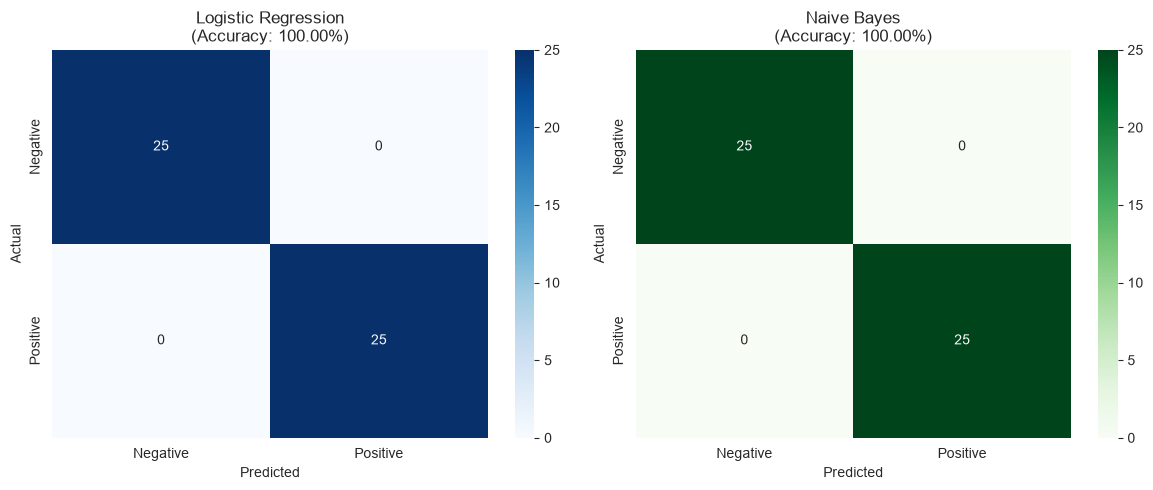

In [7]:
# Confusion Matrices

fig, axes = plt.subplots(1, 2, figsize=(12,5))

cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative','Positive'], yticklabels=['Negative','Positive'], ax=axes[0])
axes[0].set_title(f"Logistic Regression\n(Accuracy: {acc_lr:.2%})")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")

cm_nb = confusion_matrix(y_test, y_pred_nb)
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Negative','Positive'], yticklabels=['Negative','Positive'], ax=axes[1])
axes[1].set_title(f"Naive Bayes\n(Accuracy: {acc_nb:.2%})")
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

In [8]:
# Full Classification Reports

print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_lr, target_names=['Negative','Positive']))

print("=== Multinomial Naive Bayes ===")
print(classification_report(y_test, y_pred_nb, target_names=['Negative','Positive']))

=== Logistic Regression ===
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00        25
    Positive       1.00      1.00      1.00        25

    accuracy                           1.00        50
   macro avg       1.00      1.00      1.00        50
weighted avg       1.00      1.00      1.00        50

=== Multinomial Naive Bayes ===
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00        25
    Positive       1.00      1.00      1.00        25

    accuracy                           1.00        50
   macro avg       1.00      1.00      1.00        50
weighted avg       1.00      1.00      1.00        50



In [9]:
# Model Comparison Table

results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Multinomial Naive Bayes'],
    'Accuracy': [acc_lr, acc_nb],
    'Precision': [prec_lr, prec_nb],
    'Recall': [rec_lr, rec_nb],
    'F1 Score': [f1_lr, f1_nb]
})
results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,1.0,1.0,1.0,1.0
1,Multinomial Naive Bayes,1.0,1.0,1.0,1.0


In [10]:
# Inspect Most Influential Words

feature_names = tfidf.get_feature_names_out()
coefs = log_reg.coef_[0]

top_positive_idx = np.argsort(coefs)[-10:][::-1]
top_negative_idx = np.argsort(coefs)[:10]

print("Top words pushing toward POSITIVE:")
for idx in top_positive_idx:
    print(f"  {feature_names[idx]:20s} {coefs[idx]:.3f}")

print("\nTop words pushing toward NEGATIVE:")
for idx in top_negative_idx:
    print(f"  {feature_names[idx]:20s} {coefs[idx]:.3f}")

Top words pushing toward POSITIVE:
  best                 0.968
  great                0.800
  wonderful            0.738
  fantastic            0.725
  superb               0.609
  love                 0.608
  happy                0.543
  best purchase        0.543
  year happy           0.543
  outstanding performance 0.504

Top words pushing toward NEGATIVE:
  disappoint           -0.742
  dull                 -0.713
  worst                -0.618
  cheap                -0.582
  bore                 -0.582
  terrible             -0.581
  bad                  -0.540
  disappoint experience -0.499
  experience overall   -0.499
  dreadful             -0.499


In [11]:
# Test on New, Unseen Sentences

new_reviews = [
    "This was an incredible experience, I loved every second of it",
    "Absolutely terrible, do not waste your money on this",
    "Pretty average, nothing special but not bad either",
    "The service was excellent and the staff were so kind",
    "I regret buying this, complete garbage"
]

clean_new = [preprocess_text(r) for r in new_reviews]
X_new = tfidf.transform(clean_new)

preds_lr = log_reg.predict(X_new)
preds_nb = nb_model.predict(X_new)

for review, pred_lr, pred_nb in zip(new_reviews, preds_lr, preds_nb):
    label_lr = "Positive" if pred_lr == 1 else "Negative"
    label_nb = "Positive" if pred_nb == 1 else "Negative"
    print(f"Review: {review}")
    print(f"  LogisticRegression -> {label_lr} | NaiveBayes -> {label_nb}\n")

Review: This was an incredible experience, I loved every second of it
  LogisticRegression -> Positive | NaiveBayes -> Positive

Review: Absolutely terrible, do not waste your money on this
  LogisticRegression -> Negative | NaiveBayes -> Negative

Review: Pretty average, nothing special but not bad either
  LogisticRegression -> Negative | NaiveBayes -> Negative

Review: The service was excellent and the staff were so kind
  LogisticRegression -> Positive | NaiveBayes -> Positive

Review: I regret buying this, complete garbage
  LogisticRegression -> Negative | NaiveBayes -> Negative

